# 데이터셋 불러오기

In [33]:
import pandas as pd

df = pd.read_csv('C:/Users/Administrator/Dogyeom(2023.01.01)/KIST_intern/Task1/Control_Nuclear_Spins/initialize13Cspin/file/testdata.csv')
df

,Al,Ap,N,x,z,fun
0,3.484993,0.888483,13.0,1.752885,1.085551,0.032390
1,3.390258,1.763503,9.0,3.184325,2.548000,0.094200
2,1.033954,1.358603,9.0,1.463811,1.138441,0.040758
3,4.255130,0.605356,17.0,2.920000,1.788500,0.046560
4,4.746024,1.083821,13.0,2.770525,1.185844,0.026307
...,...,...,...,...,...,...
7547,3.364601,0.689352,13.0,1.783018,1.094393,0.028112
7548,2.637363,1.368201,9.0,4.273264,2.603631,0.065762
7549,4.689082,1.140467,9.0,4.026179,1.717521,0.060243
7550,1.077035,0.540976,13.0,0.492744,0.200560,0.026543


## 데이터셋 분류

In [34]:
yn = df['N']
yn

0       13.0
1        9.0
2        9.0
3       17.0
4       13.0
        ... 
7547    13.0
7548     9.0
7549     9.0
7550    13.0
7551     9.0
Name: N, Length: 7552, dtype: float64

In [35]:
yx = df['x']
yx

0       1.752885
1       3.184325
2       1.463811
3       2.920000
4       2.770525
          ...   
7547    1.783018
7548    4.273264
7549    4.026179
7550    0.492744
7551    2.902723
Name: x, Length: 7552, dtype: float64

In [36]:
yz = df['z']
yz

0       1.085551
1       2.548000
2       1.138441
3       1.788500
4       1.185844
          ...   
7547    1.094393
7548    2.603631
7549    1.717521
7550    0.200560
7551    1.784943
Name: z, Length: 7552, dtype: float64

In [37]:
X = df[['Al', 'Ap']]
X

,Al,Ap
0,3.484993,0.888483
1,3.390258,1.763503
2,1.033954,1.358603
3,4.255130,0.605356
4,4.746024,1.083821
...,...,...
7547,3.364601,0.689352
7548,2.637363,1.368201
7549,4.689082,1.140467
7550,1.077035,0.540976


## 데이터 학습/테스트 구분

In [38]:
from sklearn.model_selection import train_test_split


Xn_train, Xn_test, yn_train, yn_test = train_test_split(X, yn, test_size=0.2, random_state=100)
Xx_train, Xx_test, yx_train, yx_test = train_test_split(X, yx, test_size=0.2, random_state=100)
Xz_train, Xz_test, yz_train, yz_test = train_test_split(X, yz, test_size=0.2, random_state=100)

# 학습 모델

## lr train

In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lrx = LinearRegression()
lrz = LinearRegression()
lr.fit(Xn_train, yn_train)
lrx.fit(Xx_train, yx_train)
lrz.fit(Xz_train, yz_train)

LinearRegression()

In [40]:
yn_lr_train_pred = lr.predict(Xn_train)
yn_lr_test_pred = lr.predict(Xn_test)

yx_lr_train_pred = lrx.predict(Xx_train)
yx_lr_test_pred = lrx.predict(Xx_test)

yz_lr_train_pred = lrz.predict(Xz_train)
yz_lr_test_pred = lrz.predict(Xz_test)

## rf train

In [41]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(max_depth=2, random_state=100)
rfx = RandomForestRegressor(max_depth=2, random_state=100)
rfz = RandomForestRegressor(max_depth=2, random_state=100)

rf.fit(Xn_train, yn_train)
rfx.fit(Xx_train, yx_train)
rfz.fit(Xz_train, yz_train)

RandomForestRegressor(max_depth=2, random_state=100)

In [42]:
yn_rf_train_pred = rf.predict(Xn_train)
yn_rf_test_pred = rf.predict(Xn_test)

yx_rf_train_pred = rfx.predict(Xx_train)
yx_rf_test_pred = rfx.predict(Xx_test)

yz_rf_train_pred = rfz.predict(Xz_train)
yz_rf_test_pred = rfz.predict(Xz_test)

In [43]:
from sklearn.metrics import mean_squared_error, r2_score

rf_train_mse = mean_squared_error(yn_train, yn_rf_train_pred)
rf_train_r2 = r2_score(yn_train, yn_rf_train_pred)

rf_test_mse = mean_squared_error(yn_test, yn_rf_test_pred)
rf_test_r2 = r2_score(yn_test, yn_rf_test_pred)

In [44]:
rf_results = pd.DataFrame(['Random forest', rf_train_mse, rf_train_r2, rf_test_mse, rf_test_r2]).transpose()
rf_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']
rf_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Random forest,4.994265,0.310458,4.940665,0.333533


## SVM train

In [45]:
from sklearn.svm import SVC, SVR

cf = SVR(C=10, epsilon=0.2, kernel='linear') # SVR 생성
cfx = SVR(C=10, epsilon=0.2, kernel='linear') # SVR 생성
cfz = SVR(C=10, epsilon=0.2, kernel='linear') # SVR 생성

cf.fit(Xn_train, yn_train)
cfx.fit(Xx_train, yx_train)
cfz.fit(Xz_train, yz_train)

SVR(C=10, epsilon=0.2, kernel='linear')

In [46]:
yn_cf_train_pred = cf.predict(Xn_train)
yn_cf_test_pred = cf.predict(Xn_test)

yx_cf_train_pred = cfx.predict(Xx_train)
yx_cf_test_pred = cfx.predict(Xx_test)

yz_cf_train_pred = cfz.predict(Xz_train)
yz_cf_test_pred = cfz.predict(Xz_test)

In [47]:
from sklearn.metrics import mean_squared_error, r2_score

cf_train_mse = mean_squared_error(yn_train, yn_cf_train_pred)
cf_train_r2 = r2_score(yn_train, yn_cf_train_pred)

cf_test_mse = mean_squared_error(yn_test, yn_cf_test_pred)
cf_test_r2 = r2_score(yn_test, yn_cf_test_pred)

## KNN regression

In [48]:
from sklearn.neighbors import KNeighborsRegressor

kn = KNeighborsRegressor(n_neighbors = 14, weights = "distance")
knx = KNeighborsRegressor(n_neighbors = 14, weights = "distance")
knz = KNeighborsRegressor(n_neighbors = 14, weights = "distance")

kn.fit(Xn_train, yn_train)
knx.fit(Xx_train, yx_train)
knz.fit(Xz_train, yz_train)

KNeighborsRegressor(n_neighbors=14, weights='distance')

In [49]:
yn_kn_train_pred = kn.predict(Xn_train)
yn_kn_test_pred = kn.predict(Xn_test)

yx_kn_train_pred = knx.predict(Xx_train)
yx_kn_test_pred = knx.predict(Xx_test)

yz_kn_train_pred = knz.predict(Xz_train)
yz_kn_test_pred = knz.predict(Xz_test)

In [50]:
from sklearn.metrics import mean_squared_error, r2_score

kn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
kn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

kn_test_mse = mean_squared_error(yn_test, yn_kn_test_pred)
kn_test_r2 = r2_score(yn_test, yn_kn_test_pred)

# Figure

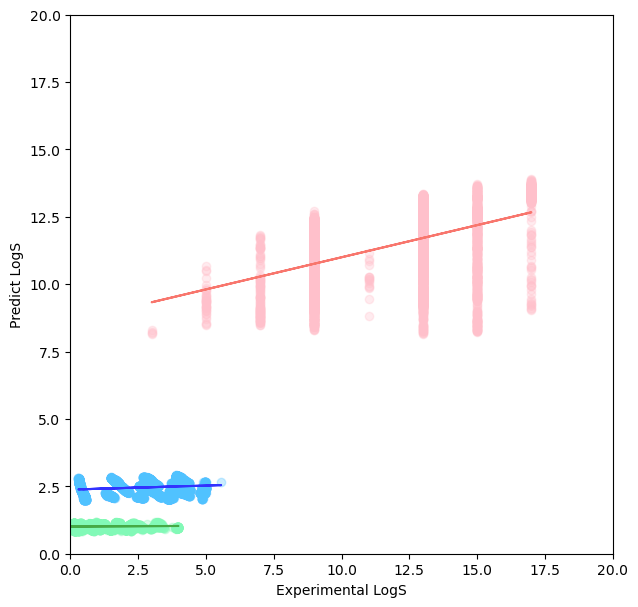

In [51]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))
plt.scatter(x=yn_train, y=yn_lr_train_pred, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx_train, y=yx_lr_train_pred, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz_train, y=yz_lr_train_pred, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn_train, yn_lr_train_pred, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx_train, yx_lr_train_pred, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz_train, yz_lr_train_pred, 1)
pz = np.poly1d(zz)

plt.plot(yn_train, pn(yn_train), '#F8766D')
plt.plot(yx_train, px(yx_train), '#3232FF')
plt.plot(yz_train, pz(yz_train), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

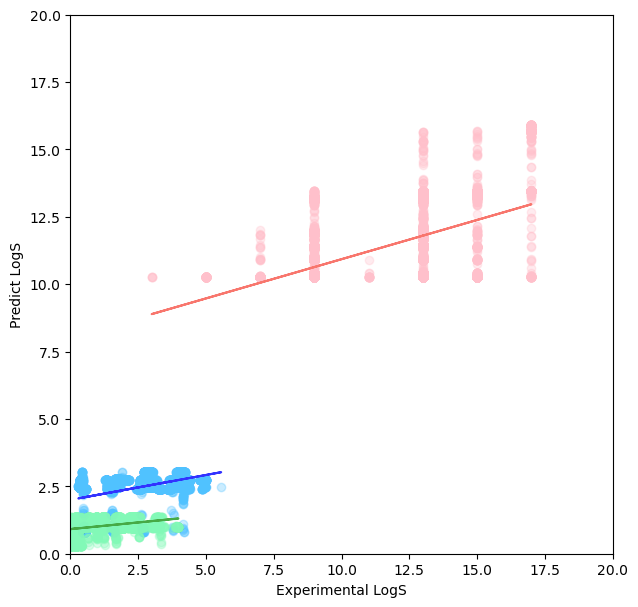

In [52]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))
plt.scatter(x=yn_train, y=yn_rf_train_pred, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx_train, y=yx_rf_train_pred, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz_train, y=yz_rf_train_pred, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn_train, yn_rf_train_pred, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx_train, yx_rf_train_pred, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz_train, yz_rf_train_pred, 1)
pz = np.poly1d(zz)

plt.plot(yn_train, pn(yn_train), '#F8766D')
plt.plot(yx_train, px(yx_train), '#3232FF')
plt.plot(yz_train, pz(yz_train), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

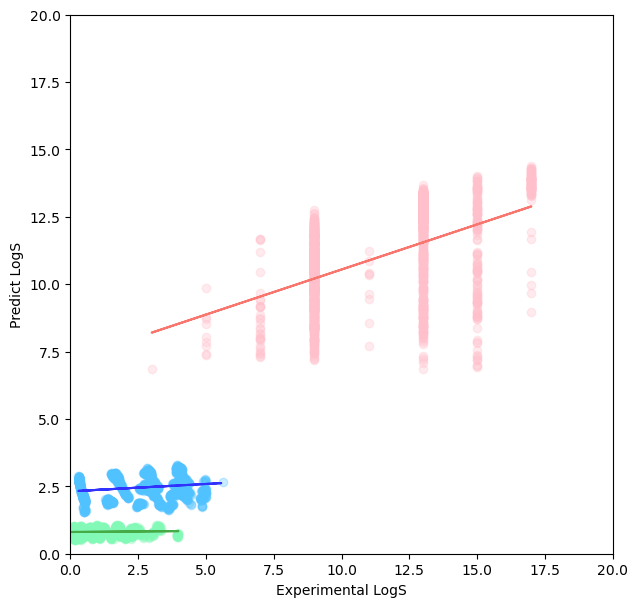

In [53]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))
plt.scatter(x=yn_test, y=yn_cf_test_pred, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx_test, y=yx_cf_test_pred, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz_test, y=yz_cf_test_pred, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn_test, yn_cf_test_pred, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx_test, yx_cf_test_pred, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz_test, yz_cf_test_pred, 1)
pz = np.poly1d(zz)

plt.plot(yn_train, pn(yn_train), '#F8766D')
plt.plot(yx_train, px(yx_train), '#3232FF')
plt.plot(yz_train, pz(yz_train), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

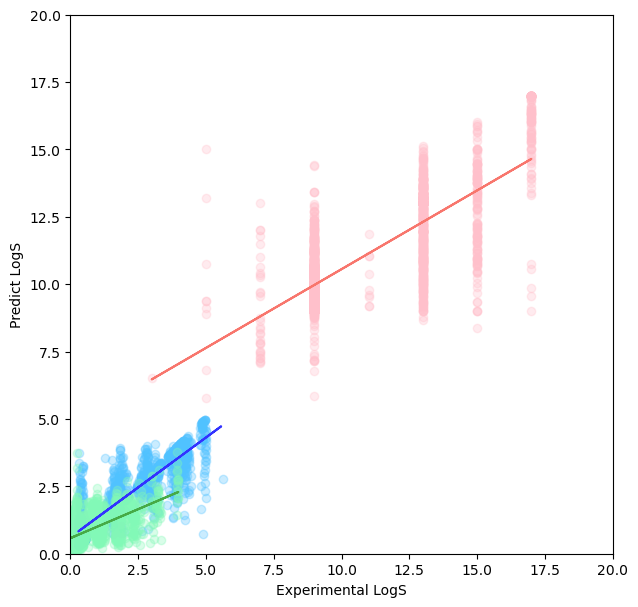

In [54]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(7,7))
plt.scatter(x=yn_test, y=yn_kn_test_pred, c="#FFC0CB" ,alpha=0.3)

plt.scatter(x=yx_test, y=yx_kn_test_pred, c="#50C2FF" ,alpha=0.3)

plt.scatter(x=yz_test, y=yz_kn_test_pred, c="#82F9B7" ,alpha=0.3)

nn = np.polyfit(yn_test, yn_kn_test_pred, 1)
pn = np.poly1d(nn)

xx = np.polyfit(yx_test, yx_kn_test_pred, 1)
px = np.poly1d(xx)

zz = np.polyfit(yz_test, yz_kn_test_pred, 1)
pz = np.poly1d(zz)

plt.plot(yn_train, pn(yn_train), '#F8766D')
plt.plot(yx_train, px(yx_train), '#3232FF')
plt.plot(yz_train, pz(yz_train), '#46AA46')
plt.ylabel('Predict LogS')
plt.xlabel('Experimental LogS')
plt.ylim(0, 20)
plt.xlim(0, 20)
plt.show()

# train 정확도 측정

## lr_train 정확도 측정

In [55]:
from sklearn.metrics import mean_squared_error, r2_score

lrn_train_mse = mean_squared_error(yn_train, yn_lr_train_pred)
lrn_train_r2 = r2_score(yn_train, yn_lr_train_pred)

lrn_test_mse = mean_squared_error(yn_test, yn_lr_test_pred)
lrn_test_r2 = r2_score(yn_test, yn_lr_test_pred)

lrx_train_mse = mean_squared_error(yx_train, yx_lr_train_pred)
lrx_train_r2 = r2_score(yx_train, yx_lr_train_pred)

lrx_test_mse = mean_squared_error(yx_test, yx_lr_test_pred)
lrx_test_r2 = r2_score(yx_test, yx_lr_test_pred)

lrz_train_mse = mean_squared_error(yz_train, yz_lr_train_pred)
lrz_train_r2 = r2_score(yz_train, yz_lr_train_pred)

lrz_test_mse = mean_squared_error(yz_test, yz_lr_test_pred)
lrz_test_r2 = r2_score(yz_test, yz_lr_test_pred)

In [56]:
print('LRN MSE (Train): ', lrn_train_mse)
print('LRN R2 (Train): ', lrn_train_r2)
print('LRN MSE (Test): ', lrn_test_mse)
print('LRN R2 (Test): ', lrn_test_r2)
print(' ')
print('LRX MSE (Train): ', lrx_train_mse)
print('LRX R2 (Train): ', lrx_train_r2)
print('LRX MSE (Test): ', lrx_test_mse)
print('LRX R2 (Test): ', lrx_test_r2)
print(' ')
print('LRZ MSE (Train): ', lrz_train_mse)
print('LRZ R2 (Train): ', lrz_train_r2)
print('LRZ MSE (Test): ', lrz_test_mse)
print('LRZ R2 (Test): ', lrz_test_r2)

LRN MSE (Train):  5.515219640789757
LRN R2 (Train):  0.23853131311438835
LRN MSE (Test):  5.409115512084849
LRN R2 (Test):  0.27034135378528357
 
LRX MSE (Train):  1.8698778081950627
LRX R2 (Train):  0.030116380648263608
LRX MSE (Test):  1.8365250595458773
LRX R2 (Test):  0.034618423536732945
 
LRZ MSE (Train):  0.7323796785773103
LRZ R2 (Train):  0.0052747851277930025
LRZ MSE (Test):  0.7129432030171922
LRZ R2 (Test):  0.006571470637980581


In [57]:
lrn_results = pd.DataFrame(['Linear regression', lrn_train_mse, lrn_train_r2, lrn_test_mse, lrn_test_r2]).transpose()
lrn_results.columns = ['Method', 'Training MSE', 'Training R2', 'Test MSE', 'Test R2']

In [58]:
lrn_results

,Method,Training MSE,Training R2,Test MSE,Test R2
0,Linear regression,5.51522,0.238531,5.409116,0.270341


## rf_train 정확도 측정

In [59]:
from sklearn.metrics import mean_squared_error, r2_score

rfn_train_mse = mean_squared_error(yn_train, yn_rf_train_pred)
rfn_train_r2 = r2_score(yn_train, yn_rf_train_pred)

rfn_test_mse = mean_squared_error(yn_test, yn_rf_test_pred)
rfn_test_r2 = r2_score(yn_test, yn_rf_test_pred)

rfx_train_mse = mean_squared_error(yx_train, yx_rf_train_pred)
rfx_train_r2 = r2_score(yx_train, yx_rf_train_pred)

rfx_test_mse = mean_squared_error(yx_test, yx_rf_test_pred)
rfx_test_r2 = r2_score(yx_test, yx_rf_test_pred)

rfz_train_mse = mean_squared_error(yz_train, yz_rf_train_pred)
rfz_train_r2 = r2_score(yz_train, yz_rf_train_pred)

rfz_test_mse = mean_squared_error(yz_test, yz_rf_test_pred)
rfz_test_r2 = r2_score(yz_test, yz_rf_test_pred)

In [60]:
print('RFN MSE (Train): ', rfn_train_mse)
print('RFN R2 (Train): ', rfn_train_r2)
print('RFN MSE (Test): ', rfn_test_mse)
print('RFN R2 (Test): ', rfn_test_r2)
print(' ')
print('RFX MSE (Train): ', rfx_train_mse)
print('RFX R2 (Train): ', rfx_train_r2)
print('RFX MSE (Test): ', rfx_test_mse)
print('RFX R2 (Test): ', rfx_test_r2)
print(' ')
print('RFZ MSE (Train): ', rfz_train_mse)
print('RFZ R2 (Train): ', rfz_train_r2)
print('RFZ MSE (Test): ', rfz_test_mse)
print('RFZ R2 (Test): ', rfz_test_r2)

RFN MSE (Train):  4.994264989231798
RFN R2 (Train):  0.31045785100146084
RFN MSE (Test):  4.940664695818037
RFN R2 (Test):  0.33353268102755884
 
RFX MSE (Train):  1.534212546768214
RFX R2 (Train):  0.20422200253249168
RFX MSE (Test):  1.5215477487845257
RFX R2 (Test):  0.20018833570996675
 
RFZ MSE (Train):  0.653342952583551
RFZ R2 (Train):  0.1126232364115064
RFZ MSE (Test):  0.6381814584835219
RFZ R2 (Test):  0.11074589801215118


## SVR_train 정확도 측정

In [61]:
from sklearn.metrics import mean_squared_error, r2_score

cfn_train_mse = mean_squared_error(yn_train, yn_cf_train_pred)
cfn_train_r2 = r2_score(yn_train, yn_cf_train_pred)

cfn_test_mse = mean_squared_error(yn_test, yn_cf_test_pred)
cfn_test_r2 = r2_score(yn_test, yn_cf_test_pred)

cfx_train_mse = mean_squared_error(yx_train, yx_cf_train_pred)
cfx_train_r2 = r2_score(yx_train, yx_cf_train_pred)

cfx_test_mse = mean_squared_error(yx_test, yx_cf_test_pred)
cfx_test_r2 = r2_score(yx_test, yx_cf_test_pred)

cfz_train_mse = mean_squared_error(yz_train, yz_cf_train_pred)
cfz_train_r2 = r2_score(yz_train, yz_cf_train_pred)

cfz_test_mse = mean_squared_error(yz_test, yz_cf_test_pred)
cfz_test_r2 = r2_score(yz_test, yz_cf_test_pred)

In [62]:
print('CFN MSE (Train): ', cfn_train_mse)
print('CFN R2 (Train): ', cfn_train_r2)
print('CFN MSE (Test): ', cfn_test_mse)
print('CFN R2 (Test): ', cfn_test_r2)
print(' ')
print('CFX MSE (Train): ', cfx_train_mse)
print('CFX R2 (Train): ', cfx_train_r2)
print('CFX MSE (Test): ', cfx_test_mse)
print('CFX R2 (Test): ', cfx_test_r2)
print(' ')
print('CFZ MSE (Train): ', cfz_train_mse)
print('CFZ R2 (Train): ', cfz_train_r2)
print('CFZ MSE (Test): ', cfz_test_mse)
print('CFZ R2 (Test): ', cfz_test_r2)

CFN MSE (Train):  5.780720586032169
CFN R2 (Train):  0.20187444914374908
CFN MSE (Test):  5.647679137108502
CFN R2 (Test):  0.23816048959742642
 
CFX MSE (Train):  1.9003105345111926
CFX R2 (Train):  0.014331283559636088
CFX MSE (Test):  1.8594241143918484
CFX R2 (Test):  0.022581383501902752
 
CFZ MSE (Train):  0.778059737630227
CFZ R2 (Train):  -0.05676831612954336
CFZ MSE (Test):  0.7573515286696828
CFZ R2 (Test):  -0.05530792937268125


## KNN_train 정확도 측정

In [63]:
from sklearn.metrics import mean_squared_error, r2_score

knn_train_mse = mean_squared_error(yn_train, yn_kn_train_pred)
knn_train_r2 = r2_score(yn_train, yn_kn_train_pred)

knn_test_mse = mean_squared_error(yn_test, yn_kn_test_pred)
knn_test_r2 = r2_score(yn_test, yn_kn_test_pred)

knx_train_mse = mean_squared_error(yx_train, yx_kn_train_pred)
knx_train_r2 = r2_score(yx_train, yx_kn_train_pred)

knx_test_mse = mean_squared_error(yx_test, yx_kn_test_pred)
knx_test_r2 = r2_score(yx_test, yx_kn_test_pred)

knz_train_mse = mean_squared_error(yz_train, yz_kn_train_pred)
knz_train_r2 = r2_score(yz_train, yz_kn_train_pred)

knz_test_mse = mean_squared_error(yz_test, yz_kn_test_pred)
knz_test_r2 = r2_score(yz_test, yz_kn_test_pred)

In [64]:
print('KNN MSE (Train): ', knn_train_mse)
print('KNN R2 (Train): ', knn_train_r2)
print('KNN MSE (Test): ', knn_test_mse)
print('KNN R2 (Test): ', knn_test_r2)
print(' ')
print('KNX MSE (Train): ', knx_train_mse)
print('KNX R2 (Train): ', knx_train_r2)
print('KNX MSE (Test): ', knx_test_mse)
print('KNX R2 (Test): ', knx_test_r2)
print(' ')
print('KNZ MSE (Train): ', knz_train_mse)
print('KNZ R2 (Train): ', knz_train_r2)
print('KNZ MSE (Test): ', knz_test_mse)
print('KNZ R2 (Test): ', knz_test_r2)

KNN MSE (Train):  0.0
KNN R2 (Train):  1.0
KNN MSE (Test):  3.145481826142739
KNN R2 (Test):  0.5756925497655554
 
KNX MSE (Train):  0.0
KNX R2 (Train):  1.0
KNX MSE (Test):  0.46822020056679226
KNX R2 (Test):  0.7538769465705591
 
KNZ MSE (Train):  0.0
KNZ R2 (Train):  1.0
KNZ MSE (Test):  0.4480823632015594
KNZ R2 (Test):  0.3756335690914089
